In [1]:
import warnings
warnings.filterwarnings('ignore')
import datetime as dt
import numpy as np
import pandas as pd
import itertools
import multiprocessing
import matplotlib.pyplot as plt
import statsmodels.api as sm
from joblib import Parallel, delayed

In [2]:
#  ---------------------------- -------------------Wind initialization ----------------------------------------------------------------------------
code_w=['000016.SH','510050.SH','IH.CFE','000300.SH','510300.SH','IF.CFE','000905.SH','000852.SH']
start_date = None

dic_data={}
dic_data['data_close_m_w']=\
    pd.read_csv('close_m_w.csv',index_col=0,parse_dates=True).loc[start_date:][code_w]
dic_data['data_high_m_w']=\
    pd.read_csv('high_m_w.csv',index_col=0,parse_dates=True).loc[start_date:][code_w]
dic_data['data_low_m_w']=\
    pd.read_csv('low_m_w.csv',index_col=0,parse_dates=True).loc[start_date:][code_w]
dic_data['data_volume_m_w']=\
    pd.read_csv('volume_m_w.csv',index_col=0,parse_dates=True).loc[start_date:][code_w]
dic_data['data_ret_d_w']=\
    pd.read_csv('ret_d_w.csv',index_col=0,parse_dates=True).loc[start_date:][code_w]

In [3]:
#  -----------------------------------------------Wind Data preprocessing -----------------------------------------------------------------------
def data_ret_m_w(newdata_close_m_w):
    df=newdata_close_m_w.copy()
    df=df.diff()/df.shift(1)
    df['datetime']=df.index
    df['date'] = pd.to_datetime(df.datetime.dt.date)
    df['time']=df.datetime.dt.time
    df = df[df.time != min(df.time)]
    df = df[df.time <= dt.time(14,57,0)]
    return df

def data_zf_m_w(newdata_high_m_w,newdata_low_m_w):
    df=(newdata_high_m_w-newdata_low_m_w)/newdata_low_m_w
    df['datetime']=df.index
    df['date'] = pd.to_datetime(df.datetime.dt.date)
    df['time']=df.datetime.dt.time
    df = df[df.time != min(df.time)]
    df = df[df.time <= dt.time(14,57,0)]
    return df

dic_data['data_ret_m_w']= data_ret_m_w(dic_data['data_close_m_w'])
dic_data['data_zf_m_w']= data_zf_m_w(dic_data['data_high_m_w'],dic_data['data_low_m_w'])

In [4]:
# ----------------------------------------------- Single-factor writing and signal processing -----------------------------------------------------------------------
def fac_cal(ret_m_w,volume_m_w,num):
    ret_d_w =  pd.DataFrame(dic_data['data_ret_d_w'][dic_fac_parameter['stkidx_code']])
    icode_w=dic_fac_parameter['icode_w'].copy()
    df=ret_m_w[icode_w].copy()
    df['datetime']=df.index
    df['date'] = pd.to_datetime(df.datetime.dt.date)
    df['time']=df.datetime.dt.time
    factor=pd.DataFrame(0,index=df.date.unique(),columns=[dic_fac_parameter['stkidx_code']])
    factor.index.name='date'
    df['vol']=volume_m_w[icode_w]
    df['p']=df[dic_fac_parameter['etf_code']].abs()/df['vol']
    df=df[~pd.isnull(df.p)]
    df=df[df['vol']>0]
    df=df[(df['time']>dic_fac_parameter['time1']) & (df['time']<dic_fac_parameter['time2'])]
    for d in df['date'].unique():
        idf=df[df['date']==d]
        idf.sort_values('p',ascending=False,inplace=True)
        idf['vp']=idf.vol.cumsum()/idf.vol.sum()
        idf=idf[idf['vp']<=num]
        f=idf[idf[dic_fac_parameter['etf_code']]>0].vol.sum()-idf[idf[dic_fac_parameter['etf_code']]<0].vol.sum()
        factor.loc[d]=f
    factor.columns = [dic_fac_parameter['stkidx_code']]
    factor = factor[dic_fac_parameter['stkidx_code']]
    ret_d_w = ret_d_w[dic_fac_parameter['stkidx_code']]
    predictions = []
    for i in range(2,len(factor)):
        # Retrieve the data of the current row
        x = factor.shift(1)[1:1+i].values.reshape(-1, 1)  # Convert the current value of A to a 2D array
        y = ret_d_w[1:1+i].values.reshape(-1, 1)  # Convert the current value of B to a 2D array
        x_with_intercept = sm.add_constant(x)
        # Build a model
        model = sm.OLS(y, x_with_intercept).fit()
        
        # Make predictions
        pred = model.predict([1,factor[i]])
        
        # Add the prediction results to the list
        predictions.append(pred[0])  # Take out the first value of the predicted result

    # Convert the prediction results to pandas Series
    predictions_df = pd.Series(predictions).to_frame()
    predictions_df.columns = [dic_fac_parameter['stkidx_code']]
    # Create a new DataFrame containing two rows of zero values
    new_rows = pd.DataFrame(np.zeros((2, 1)), columns=[dic_fac_parameter['stkidx_code']])
    # Use the pd.concat function to merge the two Dataframes along the row direction
    predictions_df = pd.concat([new_rows, predictions_df], ignore_index=True)
    predictions_df.index = factor.index
    return predictions_df

def sig_cal(factor):
    signal=np.sign(factor) * 1 # The positive and negative signs of different factors should be selected
    return signal

In [30]:
#  -----------------------------------------------Calculate the rate of return and net value------------------------------------------ --------------
def ret_cal(signal):
    real_ret=dic_data['data_ret_d_w'][dic_fac_parameter['stkidx_code']]
    real_ret=pd.DataFrame(real_ret)
    signal=signal.shift(1)# The yield rate is only available the day after the signal is issued
    ret=signal*real_ret
    ret=ret.sum(axis=1)
    ret=ret.to_frame()
    return ret

def nv_cal(ret):
    ret=ret.copy()
    ret.columns=['r']
    ret['nv']=(ret.r/100).cumsum()+1 # When calculating net value, different factors should be considered for simple interest or compound interest
    nv=ret['nv']
    return nv

In [32]:
#  -----------------------------------------------Parallel computing------------------------------------------ --------------
def parallel_execution(num):
    fac_mx_d = fac_cal(dic_data['data_ret_m_w'],dic_data['data_volume_m_w'],num)
    sig_mx_d = sig_cal(fac_mx_d)
    ret=ret_cal(sig_mx_d)

    return fac_mx_d,sig_mx_d,ret

def parallel_execution1(ret_mx_d, day, period=1):
    g_temp1 = rank_cal(ret_mx_d, day, period)
    return g_temp1

In [34]:
#  -----------------------------------------------Factor parameter preprocessing - Variables ----------------------------------------------------
dic_fac_parameter={}
dic_fac_parameter['icode_w']=['510300.SH'] 
dic_fac_parameter['stkidx_code']='000300.SH'
dic_fac_parameter['etf_code']='510300.SH'

dic_fac_parameter['time1']=dt.time(9,31,0)
dic_fac_parameter['time2']=dt.time(14,56,0)

In [36]:
#  -----------------------------------------------Evaluation function (rank format)----------------------------------------------------------------------
def max_drawdown_duration(full_nv):
    cum_max_positions = np.zeros_like(full_nv.values, dtype=int)
    for i in range(1, len(full_nv)):
        max_positions = np.argmax(full_nv.iloc[:i].values, axis=0)
        cum_max_positions[i, :] = max_positions
    max_nv_day = pd.DataFrame(cum_max_positions, columns=full_nv.columns)
    max_drawdown_day = abs(max_nv_day.sub(max_nv_day.index, axis=0)).cummax()
    mdd_rank = max_drawdown_day.rank(method='max', ascending=True, axis=1)
    return cum_max_positions, max_nv_day, mdd_rank

def daily_new_nv(full_nv):
    max_nv_day = max_drawdown_duration(full_nv)[1].diff()
    new_nv_day_num = ((max_nv_day > 0) * 1).cumsum()
    daily_new_nv_last = pd.Series(new_nv_day_num.iloc[-1] / max((len(full_nv) - 1),1), index=full_nv.columns)
    dnn_rank_last = daily_new_nv_last.rank(method='max', ascending=False)

    return dnn_rank_last

def sharp(full_nv): # 1
    full_nv = full_nv.reset_index(drop=True)
    full_ret = full_nv.diff().fillna(0)
    apr_last = pd.Series(full_nv.iloc[-1] / len(full_nv) * 242, index=full_nv.columns)  # The last line of the annualized rate of return
    r_std_last = full_ret.expanding().std().iloc[-1].fillna(0)
    sharpe_last = apr_last / r_std_last
    sharpe_last = sharpe_last.fillna(0)
    sharpe_rank_last = sharpe_last.rank(method='max', ascending=False)
    return apr_last, sharpe_rank_last  # Return the annualized rate of return and ranking

def calmar(full_nv): # 1
    max_drawdown_last = (full_nv.cummax() - full_nv).cummax().iloc[-1]
    apr_last = sharp(full_nv)[0]  # Annualized rate of return returned using the sharp function
    calmar_last = (apr_last.replace(0, pd.NaT) / max_drawdown_last.replace(0, pd.NaT)).replace(pd.NaT, 0)
    calmar_rank_last = calmar_last.rank(method='max', ascending=False)
    return calmar_rank_last


def in_max_drawdown_duration(full_nv):
    drawdown = full_nv.cummax() - full_nv
    max_drawdown = (full_nv.cummax() - full_nv).cummax()
    cum_max_positions = max_drawdown_duration(full_nv)[0]
    last_mdd = pd.DataFrame({
        col: np.argmax(np.equal(drawdown[col].values[:, None], max_drawdown[col].values), axis=0)
        for col in max_drawdown.columns
    }, index=max_drawdown.index)
    in_mdd_last = (cum_max_positions < last_mdd) * (drawdown != 0) * 999
    in_mdd_last = in_mdd_last.iloc[-1]
    return in_mdd_last


def win_ratio(full_nv):
    full_ret = full_nv.diff().fillna(0)
    win = (full_ret > 0).astype(int)
    loss = (full_ret < 0).astype(int)
    win_ratio_last = (win.cumsum().iloc[-1] / (win + loss).cumsum().iloc[-1]).fillna(0)
    win_ratio_rank_last = win_ratio_last.rank(method='max', ascending=False)
    return win_ratio_rank_last


def win_loss_ratio(full_nv):
    full_ret = full_nv.diff().fillna(0)
    win = (full_ret > 0).astype(int)
    loss = (full_ret < 0).astype(int)
    win_get = win * full_ret
    ave_win_get_last = (win_get.cumsum().iloc[-1] / win.cumsum().iloc[-1]).fillna(0)
    loss_get = loss * full_ret
    ave_loss_get_last = (loss_get.cumsum().iloc[-1] / loss.cumsum().iloc[-1]).fillna(0)
    win_loss_ratio_last = abs((ave_win_get_last.replace(0, pd.NaT) / ave_loss_get_last.replace(0, pd.NaT)).replace(pd.NaT, 0))
    win_loss_ratio_rank_last = win_loss_ratio_last.rank(method='max', ascending=False)
    return win_loss_ratio_rank_last

def rank_cal(ret_mx_d, day, period):
    if period==1:
        ret_mx_temp = ret_mx_d.iloc[0 : max(day,period)]
        # If the computation speed becomes faster in the future, this place can be +1 after max(day,period), that is, as follows:
        # ret_mx_temp = ret_mx_d.iloc[0 : max(day,period) + 1]
    else:
        ret_mx_temp = ret_mx_d.iloc[day- day // period*(period-1) : max(day,period)]
        #If the computation speed becomes faster in the future, this place can be +1 after max(day,period), that is, as follows:
        #ret_mx_temp = ret_mx_d.iloc[day- day // period*(period-1) : max(day,period) + 1]
    full_nv = ret_mx_temp.cumsum()
    
    sharpe_rank_last = sharp(full_nv)[1]
    calmar_rank_last = calmar(full_nv)
    in_mdd_last = in_max_drawdown_duration(full_nv)
    mdd_rank_last = max_drawdown_duration(full_nv)[2].iloc[-1]
    dnn_rank_last = daily_new_nv(full_nv)
    win_ratio_rank_last = win_ratio(full_nv)
    win_loss_ratio_rank_last = win_loss_ratio(full_nv)
    
    grade = sharpe_rank_last + calmar_rank_last + in_mdd_last + mdd_rank_last + dnn_rank_last + win_ratio_rank_last + win_loss_ratio_rank_last
    g_temp = pd.DataFrame(grade[grade == grade.min()].index).T
    
    return g_temp

In [ ]:
# Layer 1 parallelism
input_values = [num/100 for num in range(3, 20)]
results = Parallel(n_jobs=-1)(
    delayed(parallel_execution)(num) for num in input_values
)

ret_mx_d = pd.concat([t[2] for t in results], axis=1, ignore_index=True)
ret_mx_d.columns = input_values

sig_mx_d = pd.concat([t[1].iloc[:, 0] for t in results], axis=1, ignore_index=True)
sig_mx_d.columns = input_values

ori_ret = pd.DataFrame(dic_data['data_ret_d_w'][dic_fac_parameter['stkidx_code']])

s = pd.DataFrame()
g = pd.DataFrame()
n_day = 1

# The second layer of parallelism
input_values1 = [(ret_mx_d, day, 1) for day in range(1, int(len(ret_mx_d)/n_day)+1)]
grades_1 = Parallel(n_jobs=-1)(
    delayed(parallel_execution1)(ret_mx_d, day, 1) for day in range(1, int(len(ret_mx_d)/n_day)+1)
)

g_1 = pd.concat(grades_1, axis=0, ignore_index=True)

for d in range(1, len(ret_mx_d)+1):
    g_temp = pd.concat([grades_1[d-1]], axis=1, ignore_index=True)
    g = pd.concat([g, g_temp], axis=0, ignore_index=True)
    s_temp = np.sign(sig_mx_d[g.loc[d-1].dropna(axis=0).unique()].sum(axis=1))
    s = pd.concat([s, s_temp[(d + 0): (d + 1)]], axis=0)

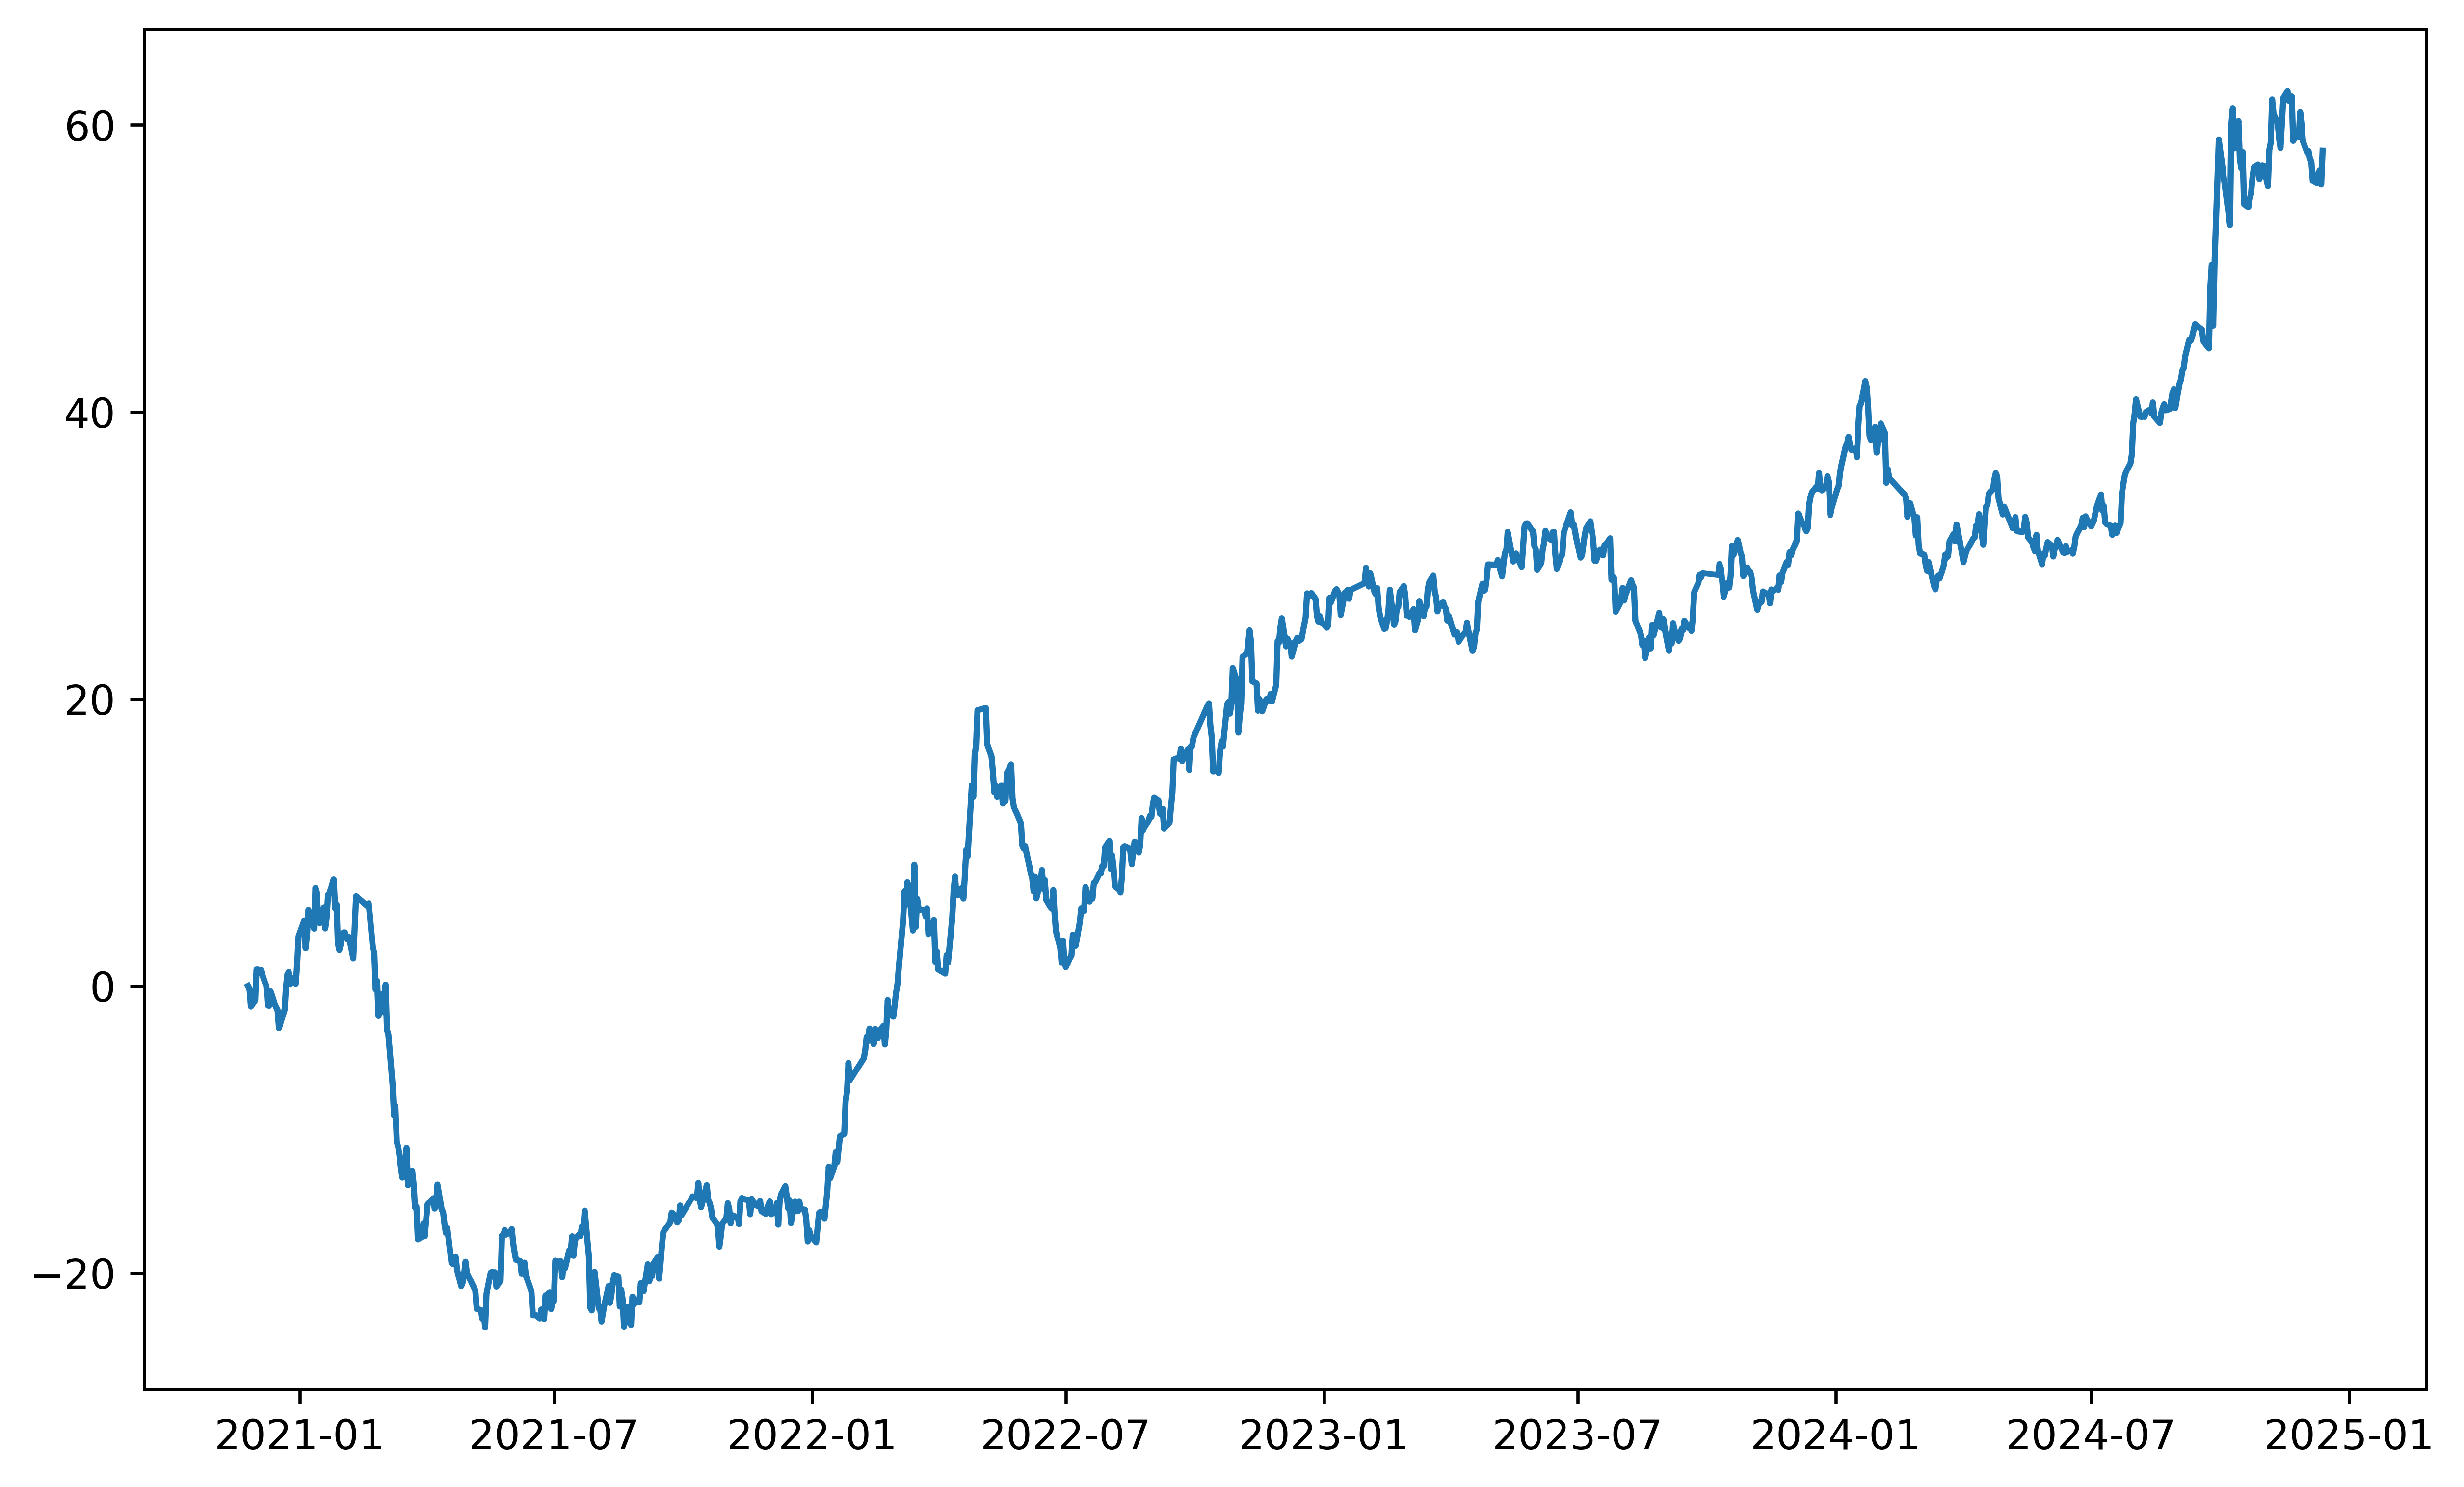

In [40]:
g.index = ori_ret.index
s.columns = [dic_fac_parameter['stkidx_code']]
r = s.shift(1) * ori_ret
nv = r.cumsum()
plt.figure(figsize=(10,6),dpi=600)
plt.plot(nv.iloc[0:])
plt.show()